# Step 2 — Data inspection & regressor construction

**5SC28 — Unbalanced Disc, ANN identification (no $\omega$)**

Goals of this notebook:
1. Load `training-val-test-data.npz` and inspect it (ranges, plots, histograms).
2. Do a temporal 80/20 train/val split.
3. Normalize $\tilde u = u/3$ (the angle stays as $(\sin\theta,\cos\theta)$, naturally bounded in $[-1,1]$).
4. Build $(X, Y)$ regressor tensors with the professor's ordering: $\varphi_k = [u_{k-n_b},\dots,u_{k-1},\,\sin\theta_{k-n_a},\cos\theta_{k-n_a},\dots,\sin\theta_{k-1},\cos\theta_{k-1}]$.
5. Verify torch + MPS, push a small batch to the GPU, save artifacts for Step 3.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from pathlib import Path

REPO_DIR = Path(
    "/Users/davidedeleonardis/Documents/TU-e/1 anno/Q4/Machine learning for systems and control/gym-unbalanced-disk-master/disc-benchmark-files"
)
WORK_DIR = Path('/Users/davidedeleonardis/Documents/TU-e/1 anno/Q4/Machine learning for systems and control/Assigment/ML4S&C-assignment')
ARTIFACTS = WORK_DIR / 'artifacts'
ARTIFACTS.mkdir(exist_ok=True)

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print('torch:', torch.__version__, '| device:', device)

torch: 2.12.0 | device: mps


## 2.1 — Load training data and basic stats

In [2]:
data = np.load(REPO_DIR / 'training-val-test-data.npz')
u_all = data['u'].astype(np.float64)
th_all = data['th'].astype(np.float64)
Ts = 0.025  # 40 Hz, from README
N = len(u_all)
print(f'N = {N} samples, duration = {N*Ts:.1f} s')

def stats(name, a):
    print(f'{name}: min={a.min():.4f}, max={a.max():.4f}, mean={a.mean():.4f}, std={a.std():.4f}')
stats('u  [V]   ', u_all)
stats('th [rad] ', th_all)
print(f'th in degrees: min={np.rad2deg(th_all.min()):.1f}, max={np.rad2deg(th_all.max()):.1f}')

N = 35000 samples, duration = 875.0 s
u  [V]   : min=-3.1027, max=3.3373, mean=0.0001, std=0.8449
th [rad] : min=-1.9007, max=2.1803, mean=0.0339, std=0.4793
th in degrees: min=-108.9, max=124.9


## 2.2 — Visual inspection: time-domain segment + histograms

Looking for: type of excitation in $u$, range coverage of $\theta$, presence of full rotations (which would justify sin/cos encoding even more strongly).

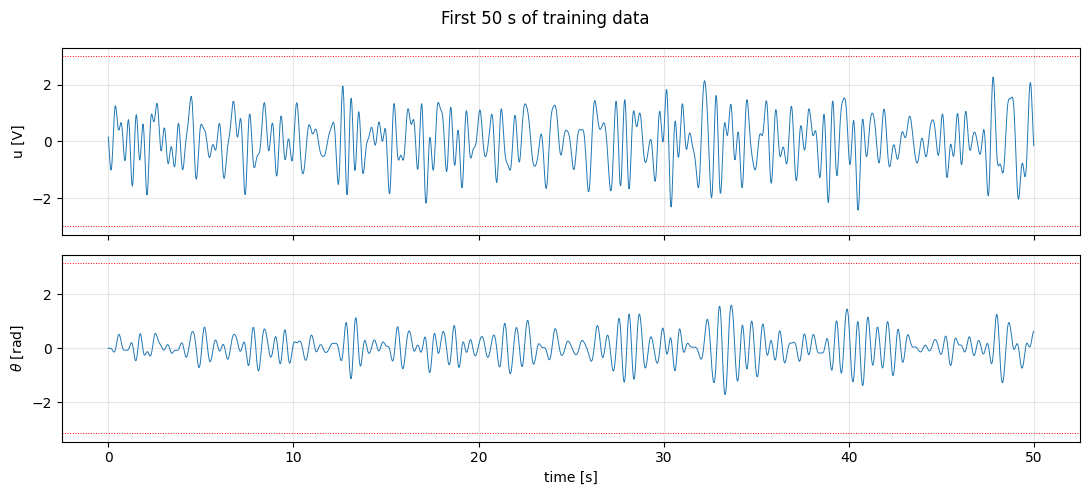

In [3]:
fig, ax = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
seg = slice(0, 2000)
t = np.arange(N)[seg] * Ts
ax[0].plot(t, u_all[seg], lw=0.7); ax[0].set_ylabel('u [V]'); ax[0].grid(alpha=0.3)
ax[0].axhline(3, c='r', ls=':', lw=0.7); ax[0].axhline(-3, c='r', ls=':', lw=0.7)
ax[1].plot(t, th_all[seg], lw=0.7); ax[1].set_ylabel(r'$\theta$ [rad]'); ax[1].set_xlabel('time [s]'); ax[1].grid(alpha=0.3)
ax[1].axhline(np.pi, c='r', ls=':', lw=0.7); ax[1].axhline(-np.pi, c='r', ls=':', lw=0.7)
plt.suptitle('First 50 s of training data')
plt.tight_layout(); plt.show()

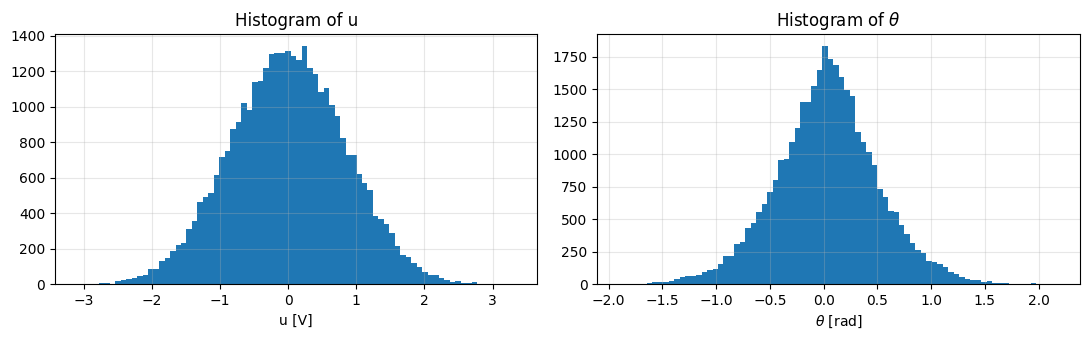

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].hist(u_all, bins=80); ax[0].set_title('Histogram of u'); ax[0].set_xlabel('u [V]'); ax[0].grid(alpha=0.3)
ax[1].hist(th_all, bins=80); ax[1].set_title(r'Histogram of $\theta$'); ax[1].set_xlabel(r'$\theta$ [rad]'); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 2.3 — Temporal 80/20 train/val split

We split **chronologically** (not random) so that the validation set reflects how the model will be tested on unseen future data.
Statistics for normalization are computed on the **train** part only.

In [5]:
split_idx = int(0.8 * N)
u_tr, u_va = u_all[:split_idx], u_all[split_idx:]
th_tr, th_va = th_all[:split_idx], th_all[split_idx:]
print(f'Train: {len(u_tr)} samples ({len(u_tr)*Ts:.1f}s)   Val: {len(u_va)} samples ({len(u_va)*Ts:.1f}s)')

# Normalization for u: divide by the saturation level (3 V), keeps geometry intact.
U_SCALE = 3.0
u_tr_n = u_tr / U_SCALE
u_va_n = u_va / U_SCALE
# theta -> (sin, cos); already in [-1, 1], no normalization needed.
sin_tr, cos_tr = np.sin(th_tr), np.cos(th_tr)
sin_va, cos_va = np.sin(th_va), np.cos(th_va)

Train: 28000 samples (700.0s)   Val: 7000 samples (175.0s)


## 2.4 — Regressor builder

Implements
$$\varphi_k = \bigl[\,u_{k-n_b},\dots,u_{k-1},\; \sin\theta_{k-n_a},\cos\theta_{k-n_a},\dots,\sin\theta_{k-1},\cos\theta_{k-1}\,\bigr]$$
with target $y_k = (\sin\theta_k,\cos\theta_k)$. The $u$-first ordering matches the example scripts in the repo, so we stay compatible with the provided submission/test conventions.

Vectorized implementation: no Python loop, so the grid search at Step 3 stays fast.

In [6]:
def create_IO_data_sincos(u_n, sin_th, cos_th, na, nb):
    """Build (X, Y) for a NARX regressor with sin/cos angle encoding.

    Parameters
    ----------
    u_n     : (N,) normalized input.
    sin_th  : (N,) sine of angle.
    cos_th  : (N,) cosine of angle.
    na, nb  : positive ints (lags on theta, lags on u).

    Returns
    -------
    X : (N - n0, nb + 2*na) regressors.
    Y : (N - n0, 2)         targets (sin, cos) at time k.
    """
    assert na >= 1 and nb >= 1
    n0 = max(na, nb)
    N = len(u_n)
    M = N - n0
    # Sliding windows by indexing (vectorized).
    idx_u  = np.arange(M)[:, None] + np.arange(n0 - nb, n0)            # (M, nb)
    idx_th = np.arange(M)[:, None] + np.arange(n0 - na, n0)            # (M, na)
    Xu  = u_n[idx_u]                                                   # (M, nb)
    Xs  = sin_th[idx_th]                                               # (M, na)
    Xc  = cos_th[idx_th]                                               # (M, na)
    # Interleave sin/cos at each lag: [sin(k-na), cos(k-na), ..., sin(k-1), cos(k-1)]
    Xsc = np.empty((M, 2 * na), dtype=Xu.dtype)
    Xsc[:, 0::2] = Xs
    Xsc[:, 1::2] = Xc
    X = np.concatenate([Xu, Xsc], axis=1).astype(np.float32)
    Y = np.stack([sin_th[n0:], cos_th[n0:]], axis=1).astype(np.float32)
    return X, Y

# Quick sanity check with one combination.
na, nb = 4, 4
Xtr, Ytr = create_IO_data_sincos(u_tr_n, sin_tr, cos_tr, na, nb)
Xva, Yva = create_IO_data_sincos(u_va_n, sin_va, cos_va, na, nb)
print(f'(na={na}, nb={nb})  Xtr {Xtr.shape}  Ytr {Ytr.shape}  Xva {Xva.shape}  Yva {Yva.shape}')
print(f'Feature dim = nb + 2*na = {nb + 2*na}')
print(f'Xtr range: [{Xtr.min():.3f}, {Xtr.max():.3f}]   Ytr range: [{Ytr.min():.3f}, {Ytr.max():.3f}]')

(na=4, nb=4)  Xtr (27996, 12)  Ytr (27996, 2)  Xva (6996, 12)  Yva (6996, 2)
Feature dim = nb + 2*na = 12
Xtr range: [-1.000, 1.112]   Ytr range: [-1.000, 1.000]


### Sanity check: a single regressor row decoded back
Verify that the row at index `i` of `Xtr` really contains the lagged $u$ first, then the interleaved $(\sin,\cos)$ pairs, and that `Ytr[i]` is consistent with $\theta_{k}$.

In [7]:
i = 0
k = max(na, nb) + i  # index in the original training stream
row = Xtr[i]
u_lags  = row[:nb]
sc_lags = row[nb:].reshape(na, 2)  # (sin, cos) per lag
print('expected u[k-nb:k] (normalized):', u_tr_n[k-nb:k])
print('row u part                    :', u_lags)
print('expected sin[k-1], cos[k-1]   :', sin_tr[k-1], cos_tr[k-1])
print('row last (sin,cos) lag        :', sc_lags[-1])
print('expected target (sin, cos)[k] :', sin_tr[k], cos_tr[k])
print('Ytr[i]                        :', Ytr[i])

expected u[k-nb:k] (normalized): [ 0.053431   -0.00964373 -0.09078523 -0.17757879]
row u part                    : [ 0.053431   -0.00964373 -0.09078523 -0.17757879]
expected sin[k-1], cos[k-1]   : 0.0 1.0
row last (sin,cos) lag        : [0. 1.]
expected target (sin, cos)[k] : 0.0 1.0
Ytr[i]                        : [0. 1.]


## 2.5 — Build all 16 grid combinations and save artifacts
Storing all $(n_a, n_b)$ combinations to disk so Step 3 (grid search) just loads them — no rebuild.

In [8]:
grid = [(na, nb) for na in (2, 4, 6, 8) for nb in (2, 4, 6, 8)]
datasets = {}
for (na, nb) in grid:
    Xtr, Ytr = create_IO_data_sincos(u_tr_n, sin_tr, cos_tr, na, nb)
    Xva, Yva = create_IO_data_sincos(u_va_n, sin_va, cos_va, na, nb)
    datasets[(na, nb)] = (Xtr, Ytr, Xva, Yva)
    print(f'(na={na}, nb={nb})  in_dim={Xtr.shape[1]:>2}  Ntr={Xtr.shape[0]}  Nva={Xva.shape[0]}')

# Save raw normalized signals + split info; Step 3 can rebuild on the fly or use cached.
np.savez(
    ARTIFACTS / 'step2_processed.npz',
    u_tr_n=u_tr_n, u_va_n=u_va_n,
    sin_tr=sin_tr, cos_tr=cos_tr,
    sin_va=sin_va, cos_va=cos_va,
    th_tr=th_tr, th_va=th_va,
    U_SCALE=np.float64(U_SCALE), Ts=np.float64(Ts), split_idx=np.int64(split_idx),
)
print(f'\nSaved to {ARTIFACTS / "step2_processed.npz"}')

(na=2, nb=2)  in_dim= 6  Ntr=27998  Nva=6998
(na=2, nb=4)  in_dim= 8  Ntr=27996  Nva=6996
(na=2, nb=6)  in_dim=10  Ntr=27994  Nva=6994
(na=2, nb=8)  in_dim=12  Ntr=27992  Nva=6992
(na=4, nb=2)  in_dim=10  Ntr=27996  Nva=6996
(na=4, nb=4)  in_dim=12  Ntr=27996  Nva=6996
(na=4, nb=6)  in_dim=14  Ntr=27994  Nva=6994
(na=4, nb=8)  in_dim=16  Ntr=27992  Nva=6992
(na=6, nb=2)  in_dim=14  Ntr=27994  Nva=6994
(na=6, nb=4)  in_dim=16  Ntr=27994  Nva=6994
(na=6, nb=6)  in_dim=18  Ntr=27994  Nva=6994
(na=6, nb=8)  in_dim=20  Ntr=27992  Nva=6992
(na=8, nb=2)  in_dim=18  Ntr=27992  Nva=6992
(na=8, nb=4)  in_dim=20  Ntr=27992  Nva=6992
(na=8, nb=6)  in_dim=22  Ntr=27992  Nva=6992
(na=8, nb=8)  in_dim=24  Ntr=27992  Nva=6992

Saved to /Users/davidedeleonardis/Documents/TU-e/1 anno/Q4/Machine learning for systems and control/Assigment/ML4S&C-assignment/artifacts/step2_processed.npz


## 2.6 — Verify MPS round-trip
Push one combination to MPS and run a dummy forward through a tiny linear layer to confirm the device works end-to-end.

In [9]:
Xtr, Ytr, Xva, Yva = datasets[(4, 4)]
Xtr_t = torch.from_numpy(Xtr).to(device)
Ytr_t = torch.from_numpy(Ytr).to(device)
lin = torch.nn.Linear(Xtr.shape[1], 2).to(device)
with torch.no_grad():
    out = lin(Xtr_t[:8])
print('forward OK on', out.device, '| out shape:', tuple(out.shape))

forward OK on mps:0 | out shape: (8, 2)


---
**End of Step 2.**

Outputs you should look at before moving on:
- The two plots (time-domain + histograms) — confirm that $u$ excites the system across $[-3,+3]$ and that $\theta$ visits the full range of interest ($\pm$120°).
- The sanity-check cell — confirm the regressor row decodes correctly.
- MPS round-trip succeeded.

Step 3 will: define the MLP $f_\varphi$, training loop with early stopping, and grid search over the 16 combinations of $(n_a, n_b)$.